# 05 · Audience Segmentation (Model C)
K-Means clustering over behavioural features. K is chosen with the elbow method and confirmed with silhouette score, then each cluster is profiled in business language.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
from clustering import run_clustering
df = pd.read_csv('../data/adcore_features.csv', parse_dates=['timestamp'])
results = run_clustering(df, k=4)
print('K selected:', results['k_selected'])
print('Silhouette score:', results['final_silhouette_score'])

K selected: 4
Silhouette score: 0.3363


## Elbow method: inertia & silhouette vs K

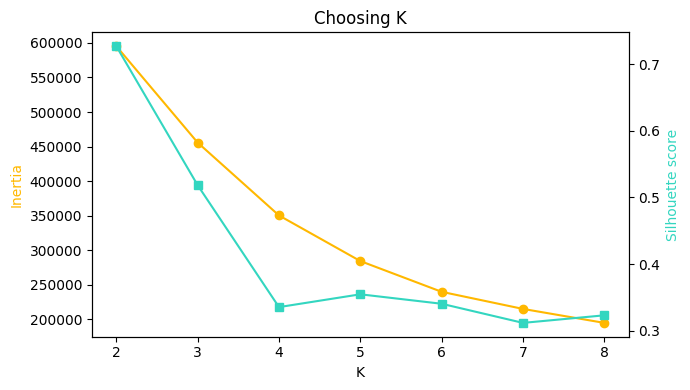

In [2]:
import matplotlib.pyplot as plt
search = results['elbow_silhouette_search']
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(search['k_values'], search['inertia'], marker='o', color='#FFB800')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia', color='#FFB800')
ax2 = ax1.twinx()
ax2.plot(search['k_values'], search['silhouette'], marker='s', color='#33D6C0')
ax2.set_ylabel('Silhouette score', color='#33D6C0')
ax1.set_title('Choosing K'); plt.tight_layout(); plt.show()

## Cluster profiles (business language)

In [3]:
pd.DataFrame(results['cluster_profiles']).set_index('cluster')

,size,pct_of_users,label,avg_session_duration,avg_ctr,avg_cvr,avg_revenue,avg_content_affinity,avg_pages_viewed
cluster,,,,,,,,,
1,5741,3.83,High-value highly engaged audience,25.29,0.1940,0.8838,23.24,0.1927,3.47
3,6960,4.64,High-value casual click-responsive audience,23.30,0.4113,0.0112,1.31,0.4092,3.29
0,49106,32.74,Low-value highly engaged audience,36.47,0.0235,0.0002,0.17,0.0236,5.03
2,88193,58.80,Low-value casual audience,15.19,0.0206,0.0001,0.15,0.0208,2.30


## Segment scatter: session duration vs. revenue

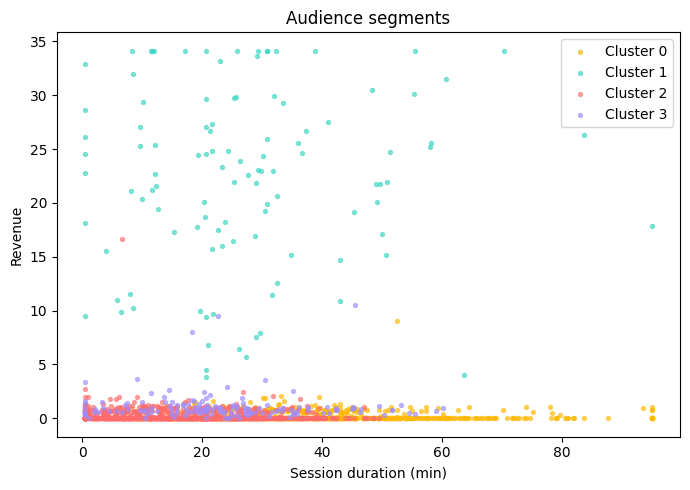

In [4]:
import pandas as pd
scatter = pd.DataFrame(results['scatter_sample'])
fig, ax = plt.subplots(figsize=(7,5))
colors = ['#FFB800','#33D6C0','#FF6B6B','#9C8CFF']
for c, sub in scatter.groupby('cluster'):
    ax.scatter(sub['session_duration'], sub['revenue'], s=8,
               color=colors[c % len(colors)], label=f'Cluster {c}', alpha=0.6)
ax.set_xlabel('Session duration (min)'); ax.set_ylabel('Revenue')
ax.legend(); ax.set_title('Audience segments')
plt.tight_layout(); plt.show()